# Grokking hyperparameter sweep + accuracy grid

Combinatorial sweep over the grokking setup defined in
`Group23-grok_train.ipynb`. The model and dataset code are **imported from that
notebook** (extracted and executed at runtime) so this notebook never duplicates
the architecture — change the source notebook and re-run cell 1 to pick it up.

**Sweep grid**

| dimension | values | n |
|---|---|---|
| `train_frac` | 0.05, 0.1, 0.2, 0.3, 0.6 | 5 |
| `weight_decay` | 0.01, 1.0, 3.0 | 3 |
| `seed` | 1, 2, 3 | 3 |
| `causal` | `False` (fixed) | — |

→ **45 runs**, 30 000 epochs each. Results stream to `sweep_results/` (one JSON per
run + a flat `index.jsonl`), so an interrupted run resumes where it left off and
re-plotting never requires re-training. Batch size follows the notebook's
"full batch but sampled with replacement" policy: `int(P**N_INPUTS * train_frac)`.


## 1) Model import and dataset code

In [1]:
import json, types

NB_SRC = "Group23-grok_train_ckpt.ipynb"   # source notebook for the model/dataset code

def load_defs_from_notebook(path):
    """Exec the code cells of `path` that define the model classes and the
    dataset helpers, and return them in a namespace. We only run the cells that
    contain the definitions (not the training loop / plotting cells), so this is
    safe to import from."""
    nb = json.load(open(path))
    ns = {}
    wanted = ("class Attention", "class TransformerBlock", "class GrokTransformer",
              "def make_dataset", "def embedding_diagnostics")
    # base imports the defs rely on
    exec("import math\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F", ns)
    for cell in nb["cells"]:
        if cell["cell_type"] != "code":
            continue
        src = "".join(cell["source"])
        if any(tok in src for tok in wanted):
            exec(src, ns)
    return ns

_defs = load_defs_from_notebook(NB_SRC)
GrokTransformer       = _defs["GrokTransformer"]
make_dataset          = _defs["make_dataset"]
print("Imported:", [k for k in ("GrokTransformer", "make_dataset") if k in _defs])

Imported: ['GrokTransformer', 'make_dataset']


## 2) Grid search configuration

In [2]:
import os, time, itertools
from datetime import timedelta
import torch
import torch.nn.functional as F

# ---- fixed task / model config (identical to the source notebook) ----
P, N_INPUTS              = 37, 3
D_MODEL, N_HEADS         = 128, 4
N_LAYERS, D_FF           = 2, 4 * 128
CAUSAL                   = False          # fixed for this sweep
LR, LR_MIN, BETAS        = 1e-3, 1e-4, (0.9, 0.98)
N_STEPS, LOG_EVERY       = 30_000, 100

# ---- sweep grid ----
TRAIN_FRACS   = [0.05, 0.1, 0.2, 0.3, 0.6]
WEIGHT_DECAYS = [0.01, 1.0, 3.0]
SEEDS         = [1, 2, 3]

RESULTS_DIR = "sweep_results"
USE_FLOAT64 = True        # clean grokking curves; set False for ~30-40% speedup

DEVICE = torch.device("cuda" if torch.cuda.is_available() else
                      ("mps" if getattr(torch.backends, "mps", None) and
                       torch.backends.mps.is_available() else "cpu"))
DTYPE  = torch.float64 if USE_FLOAT64 else torch.float32
print(f"device={DEVICE} | dtype={DTYPE} | causal={CAUSAL}")
print(f"{len(TRAIN_FRACS)*len(WEIGHT_DECAYS)*len(SEEDS)} runs "
      f"({len(TRAIN_FRACS)} x {len(WEIGHT_DECAYS)} x {len(SEEDS)})")


device=cuda | dtype=torch.float64 | causal=False
45 runs (5 x 3 x 3)


## 3) Training with I/O helpers

In [3]:
def run_id(train_frac, weight_decay, seed):
    return f"frac{train_frac:g}_wd{weight_decay:g}_seed{seed}"

def build_split(train_frac, seed):
    inputs, targets = make_dataset(P, N_INPUTS)
    n_total = inputs.size(0)
    perm = torch.randperm(n_total, generator=torch.Generator().manual_seed(seed))
    n_train = int(n_total * train_frac)
    tr, va = perm[:n_train], perm[n_train:]
    return (inputs[tr].to(DEVICE), targets[tr].to(DEVICE),
            inputs[va].to(DEVICE), targets[va].to(DEVICE), n_train)

def train_one(train_frac, weight_decay, seed, n_steps=N_STEPS, log_every=LOG_EVERY):
    torch.manual_seed(seed)
    train_x, train_y, val_x, val_y, n_train = build_split(train_frac, seed)

    # full batch but sampled WITH replacement: one draw per training example
    batch_size = int(P ** N_INPUTS * train_frac)
    assert batch_size == train_x.size(0), (batch_size, train_x.size(0))

    model = GrokTransformer(P, N_INPUTS, D_MODEL, N_HEADS, N_LAYERS, D_FF,
                            CAUSAL).to(DEVICE).to(DTYPE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, betas=BETAS,
                            weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_steps, eta_min=LR_MIN)
    gen = torch.Generator(device=DEVICE).manual_seed(seed + 100_000)

    history = {k: [] for k in
               ["step", "train_loss", "val_loss", "train_acc", "val_acc", "weight_norm"]}
    t0 = time.time()
    for step in range(n_steps + 1):
        model.train()
        idx = torch.randint(0, train_x.size(0), (batch_size,), generator=gen, device=DEVICE)
        loss = F.cross_entropy(model(train_x[idx]), train_y[idx])
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step(); sched.step()

        if step % log_every == 0:
            model.eval()
            with torch.no_grad():
                tl = model(train_x)
                train_acc  = (tl.argmax(-1) == train_y).float().mean().item()
                train_loss = F.cross_entropy(tl, train_y).item()
                vl = model(val_x)
                val_loss = F.cross_entropy(vl, val_y).item()
                val_acc  = (vl.argmax(-1) == val_y).float().mean().item()
                wn = sum(p.pow(2).sum().item() for p in model.parameters()) ** 0.5
            for k, v in zip(history,
                            [step, train_loss, val_loss, train_acc, val_acc, wn]):
                history[k].append(v)

    return {
        "run_id": run_id(train_frac, weight_decay, seed),
        "config": dict(p=P, n_inputs=N_INPUTS, train_frac=train_frac,
                       weight_decay=weight_decay, seed=seed, causal=CAUSAL,
                       d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, d_ff=D_FF,
                       lr=LR, lr_min=LR_MIN, betas=list(BETAS), n_steps=n_steps,
                       batch_size=batch_size, n_train=n_train, dtype=str(DTYPE)),
        "history": history,
        "final": {k: history[k][-1] for k in history},
        "elapsed_sec": time.time() - t0,
    }

def save_run(result):
    os.makedirs(RESULTS_DIR, exist_ok=True)
    with open(os.path.join(RESULTS_DIR, result["run_id"] + ".json"), "w") as f:
        json.dump(result, f)
    with open(os.path.join(RESULTS_DIR, "index.jsonl"), "a") as f:
        f.write(json.dumps({"run_id": result["run_id"],
                            **result["config"], **result["final"],
                            "elapsed_sec": result["elapsed_sec"]}) + "\n")


## 4) Main grid search run

Streams each finished run to `sweep_results/`. Re-running this cell **skips runs
already on disk**, so it is safe to interrupt and resume.

In [5]:
configs = list(itertools.product(TRAIN_FRACS, WEIGHT_DECAYS, SEEDS))
sweep_t0 = time.time()
for i, (frac, wd, seed) in enumerate(configs, 1):
    rid = run_id(frac, wd, seed)
    if os.path.exists(os.path.join(RESULTS_DIR, rid + ".json")):
        print(f"[{i:3d}/{len(configs)}] skip (done): {rid}")
        continue
    print(f"[{i:3d}/{len(configs)}] {rid} ...", flush=True)
    res = train_one(frac, wd, seed)
    save_run(res)
    elapsed = time.time() - sweep_t0
    eta = elapsed / i * (len(configs) - i)
    print(f"      {res['elapsed_sec']:.1f}s  val_acc={res['final']['val_acc']:.3f}  "
          f"| elapsed {timedelta(seconds=int(elapsed))}  ETA {timedelta(seconds=int(eta))}",
          flush=True)
print(f"\nSweep complete in {timedelta(seconds=int(time.time()-sweep_t0))}.")

[  1/45] skip (done): frac0.05_wd0.01_seed1
[  2/45] skip (done): frac0.05_wd0.01_seed2
[  3/45] skip (done): frac0.05_wd0.01_seed3
[  4/45] skip (done): frac0.05_wd1_seed1
[  5/45] skip (done): frac0.05_wd1_seed2
[  6/45] skip (done): frac0.05_wd1_seed3
[  7/45] skip (done): frac0.05_wd3_seed1
[  8/45] skip (done): frac0.05_wd3_seed2
[  9/45] skip (done): frac0.05_wd3_seed3
[ 10/45] skip (done): frac0.1_wd0.01_seed1
[ 11/45] skip (done): frac0.1_wd0.01_seed2
[ 12/45] skip (done): frac0.1_wd0.01_seed3
[ 13/45] skip (done): frac0.1_wd1_seed1
[ 14/45] skip (done): frac0.1_wd1_seed2
[ 15/45] skip (done): frac0.1_wd1_seed3
[ 16/45] skip (done): frac0.1_wd3_seed1
[ 17/45] skip (done): frac0.1_wd3_seed2
[ 18/45] skip (done): frac0.1_wd3_seed3
[ 19/45] skip (done): frac0.2_wd0.01_seed1
[ 20/45] skip (done): frac0.2_wd0.01_seed2
[ 21/45] skip (done): frac0.2_wd0.01_seed3
[ 22/45] skip (done): frac0.2_wd1_seed1
[ 23/45] skip (done): frac0.2_wd1_seed2
[ 24/45] skip (done): frac0.2_wd1_seed3
[ 25

## 5) Plotting (accuracy grid)

Each subplot overlays the 4 seeds at `alpha=0.5`.
Reads results from disk, so it can be re-run independently of the sweep.

loaded 45 runs


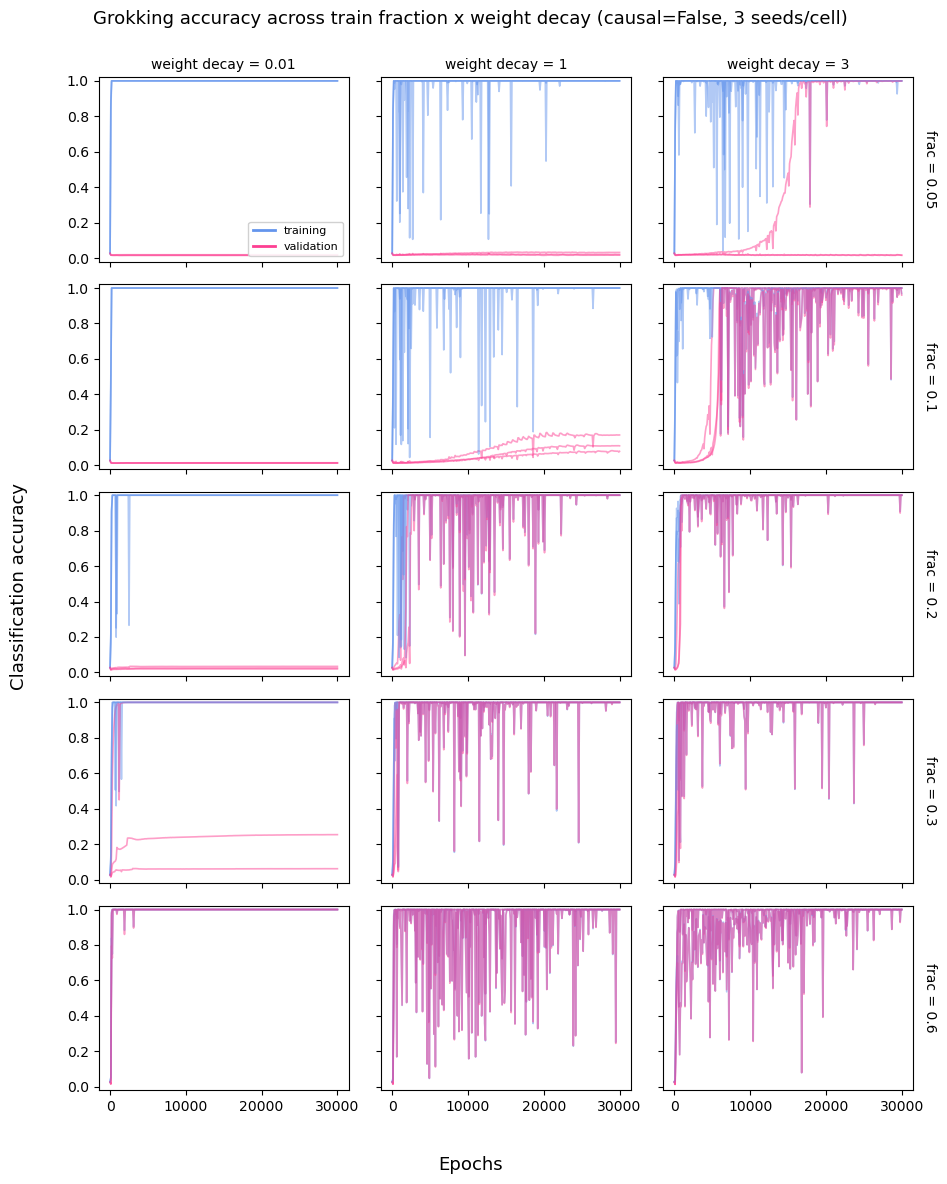

saved accuracy_grid.png


In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

TRAIN_COLOR = "cornflowerblue"
VAL_COLOR   = "#FD3F92"          # "French fuchsia"
ALPHA       = 0.5

def load_results(results_dir=RESULTS_DIR):
    """run_id -> result dict, for every <run_id>.json present."""
    out = {}
    if not os.path.isdir(results_dir):
        return out
    for fn in os.listdir(results_dir):
        if fn.endswith(".json"):
            r = json.load(open(os.path.join(results_dir, fn)))
            out[r["run_id"]] = r
    return out

results = load_results()
print(f"loaded {len(results)} runs")

nrows, ncols = len(TRAIN_FRACS), len(WEIGHT_DECAYS)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.4 * nrows),
                         sharex=True, sharey=True, squeeze=False)

for r, frac in enumerate(TRAIN_FRACS):
    for c, wd in enumerate(WEIGHT_DECAYS):
        ax = axes[r][c]
        for seed in SEEDS:
            res = results.get(run_id(frac, wd, seed))
            if res is None:
                continue
            steps = res["history"]["step"]
            ax.plot(steps, res["history"]["train_acc"], color=TRAIN_COLOR, alpha=ALPHA, lw=1.2)
            ax.plot(steps, res["history"]["val_acc"],   color=VAL_COLOR,   alpha=ALPHA, lw=1.2)
        ax.set_ylim(-0.02, 1.02)
        if r == 0:
            ax.set_title(f"weight decay = {wd:g}", fontsize=10)
        if c == ncols - 1:
            ax.text(1.04, 0.5, f"frac = {frac:g}", transform=ax.transAxes,
                    rotation=270, va="center", ha="left", fontsize=10)

# color legend on the first subplot only
axes[0][0].legend(handles=[Line2D([0], [0], color=TRAIN_COLOR, lw=2, label="training"),
                           Line2D([0], [0], color=VAL_COLOR,   lw=2, label="validation")],
                  loc="lower right", fontsize=8, framealpha=0.9)

# single shared axis labels for the whole figure
fig.supxlabel("Epochs", fontsize=13)
fig.supylabel("Classification accuracy", fontsize=13)
fig.suptitle("Grokking accuracy across train fraction x weight decay "
             f"(causal={CAUSAL}, {len(SEEDS)} seeds/cell)", fontsize=13)
fig.tight_layout(rect=[0.02, 0.02, 1, 0.98])
fig.savefig("accuracy_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved accuracy_grid.png")
